# 多模态：CLIP 与 MAE 的真实模型实验

CPU 可运行；首次下载两套模型权重，合计超过 1 GB，建议至少 4 GB 空闲内存。默认使用明确标注的合成色块图，无外部图片版权问题；改 IMAGE_PATH 使用自己的图片。依赖 transformers 4.57.1。合成图上的分数不代表现实图像质量。

执行状态：编写时已在 CPU 上运行，下方为真实输出；CUDA/TPU 路径未经测试。请重新运行以获取你的环境结果。

In [1]:
import sys, subprocess, importlib.util
needed = [p for p in ['torch','transformers','numpy','matplotlib','PIL'] if importlib.util.find_spec(p) is None]
if needed:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'torch>=2.6,<3', 'transformers==4.57.1', 'numpy', 'matplotlib', 'pillow'])
import torch, numpy as np, matplotlib.pyplot as plt, transformers
print({'python':sys.version.split()[0], 'torch':torch.__version__, 'transformers':transformers.__version__, 'cuda':torch.cuda.is_available()})
torch.manual_seed(7); np.random.seed(7)
torch.set_num_threads(min(4, torch.get_num_threads()))


{'python': '3.12.14', 'torch': '2.14.0+cpu', 'transformers': '4.57.1', 'cuda': False}


## 1 · 准备输入并检查 patch 往返
先检查通道与空间顺序，再加载模型。

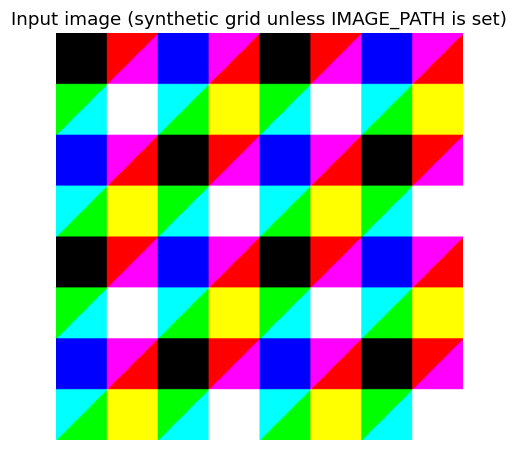

patches: torch.Size([1, 196, 768])


In [2]:
from PIL import Image
IMAGE_PATH = ''
if IMAGE_PATH:
    image=Image.open(IMAGE_PATH).convert('RGB')
else:
    yy,xx=np.mgrid[:224,:224]
    pixels=np.stack([(xx//28%2)*255,(yy//28%2)*255,((xx+yy)//56%2)*255],axis=-1).astype('uint8')
    image=Image.fromarray(pixels)
plt.imshow(image);plt.title('Input image (synthetic grid unless IMAGE_PATH is set)');plt.axis('off');plt.show()
x=torch.tensor(np.asarray(image.resize((224,224))).copy()).permute(2,0,1)[None].float()/255
patches=x.reshape(1,3,14,16,14,16).permute(0,2,4,1,3,5).reshape(1,196,768)
restored=patches.reshape(1,14,14,3,16,16).permute(0,3,1,4,2,5).reshape_as(x)
assert torch.equal(x,restored)
print('patches:',patches.shape)


## 2 · 加载真实 CLIP
修改候选描述，观察条件 softmax 如何随候选集合变化。

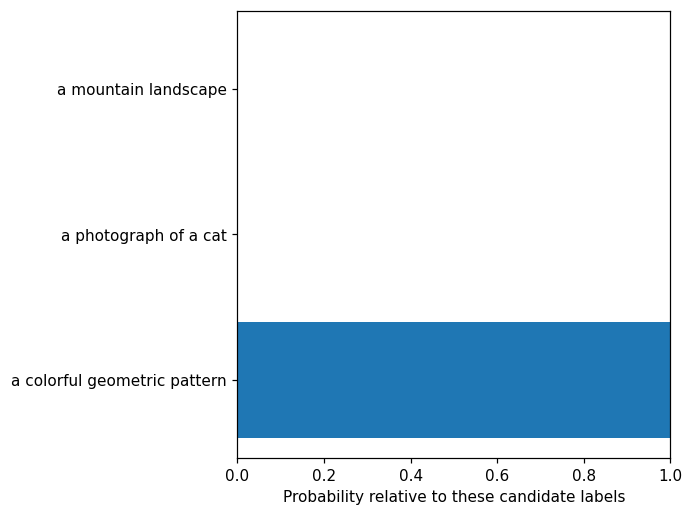

{'pixel_values': (1, 3, 224, 224), 'input_ids': (3, 7), 'attention_mask': (3, 7)}
image embedding: torch.Size([1, 512]) text embeddings: torch.Size([3, 512])
resolved revision: 3d74acf9a28c67741b2f4f2ea7635f0aaf6f0268
a colorful geometric pattern 0.99994
a photograph of a cat 1e-05
a mountain landscape 5e-05


In [3]:
from transformers import CLIPModel, AutoProcessor
clip_id='openai/clip-vit-base-patch32'
clip=CLIPModel.from_pretrained(clip_id).eval()
processor=AutoProcessor.from_pretrained(clip_id)
labels=['a colorful geometric pattern','a photograph of a cat','a mountain landscape']
clip_inputs=processor(text=labels,images=image,return_tensors='pt',padding=True)
with torch.no_grad(): clip_out=clip(**clip_inputs)
print({k:tuple(v.shape) for k,v in clip_inputs.items()})
print('image embedding:',clip_out.image_embeds.shape,'text embeddings:',clip_out.text_embeds.shape)
print('resolved revision:',clip.config._commit_hash)
prob=clip_out.logits_per_image.softmax(-1)[0]
for label,p in zip(labels,prob.tolist()):print(label,round(p,5))
plt.barh(labels,prob.numpy());plt.xlim(0,1);plt.xlabel('Probability relative to these candidate labels');plt.tight_layout();plt.show()
del clip,clip_out,clip_inputs
import gc;gc.collect()


## 3 · 加载真实 MAE，改变 mask ratio
固定随机 seed 保持 mask 可复现。读取 norm_pix_loss 决定是否需恢复 patch 目标尺度。

In [4]:
from transformers import ViTMAEForPreTraining, AutoImageProcessor
mae_id='facebook/vit-mae-base'
mae=ViTMAEForPreTraining.from_pretrained(mae_id).eval()
image_processor=AutoImageProcessor.from_pretrained(mae_id)
MASK_RATIO=.75
assert 0 < MASK_RATIO < 1
mae.config.mask_ratio=MASK_RATIO
mae_inputs=image_processor(images=image,return_tensors='pt')
torch.manual_seed(7)
with torch.no_grad(): mae_out=mae(**mae_inputs)
print('resolved revision:',mae.config._commit_hash)
print('pixels:',mae_inputs['pixel_values'].shape,'logits:',mae_out.logits.shape)
print('masked patches:',mae_out.mask.sum().item(),'loss:',mae_out.loss.item())
assert torch.isfinite(mae_out.loss)


resolved revision: 25b184bea5538bf5c4c852c79d221195fdd2778d
pixels: torch.Size([1, 3, 224, 224]) logits: torch.Size([1, 196, 768])
masked patches: 147.0 loss: 0.5045755505561829


## 4 · 显示真实重建
可见区域沿用输入，隐藏区域使用预测。若使用 normalized pixel targets，恢复目标统计仅用于诊断显示，不是部署时知道隐藏真值的方案。

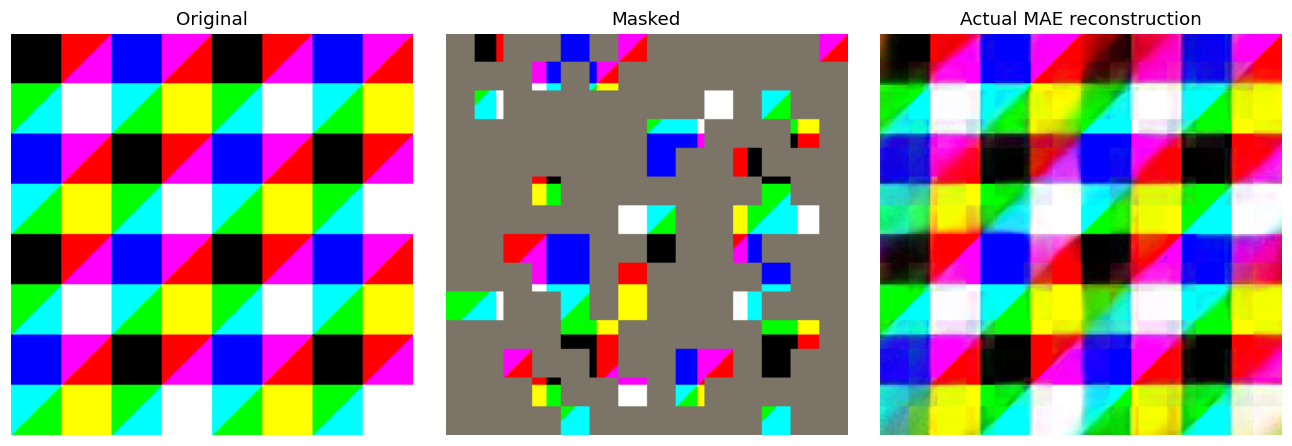

In [5]:
pixel_values=mae_inputs['pixel_values']
pred=mae_out.logits
if mae.config.norm_pix_loss:
    target=mae.patchify(pixel_values)
    mean=target.mean(-1,keepdim=True)
    var=target.var(-1,keepdim=True)
    pred=pred*(var+1e-6).sqrt()+mean
reconstruction=mae.unpatchify(pred)
mask=mae.unpatchify(mae_out.mask.unsqueeze(-1).repeat(1,1,pred.shape[-1]))
mean=torch.tensor(image_processor.image_mean).view(1,3,1,1)
std=torch.tensor(image_processor.image_std).view(1,3,1,1)
def display_pixels(t):return ((t*std+mean).clamp(0,1)[0].permute(1,2,0)).numpy()
original=display_pixels(pixel_values)
masked=display_pixels(pixel_values*(1-mask))
filled=display_pixels(pixel_values*(1-mask)+reconstruction*mask)
fig,axes=plt.subplots(1,3,figsize=(12,4))
for ax,img,title in zip(axes,[original,masked,filled],['Original','Masked','Actual MAE reconstruction']):
    ax.imshow(img);ax.set_title(title);ax.axis('off')
plt.tight_layout();plt.show()


## 下一步
改变一个参数，先预测结果，再重跑。记录环境、seed、输入与失败情况；不要把教学实验外推成生产结论。